# 01. Khám phá Dữ liệu & Phân tích Fourier

Notebook này thực hiện các bước phân tích dữ liệu khám phá (EDA) cho bộ dữ liệu `ETTm2`, bao gồm:
- Kiểm tra giá trị khuyết thiếu (missing values) và tính đều đặn của tần suất lấy mẫu.
- Phát hiện và phân tích các giá trị ngoại lệ (outliers).
- Khử xu hướng (detrending) và phân tích phổ tần số bằng thuật toán biến đổi Fourier nhanh (FFT).
- Nhận diện các chu kỳ mùa vụ nổi bật nhất.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend, find_peaks

from src.data_loader import load_data, check_data_quality

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Tải dữ liệu & Xem thông số cơ bản

In [2]:
filepath = "../data/raw/ETTm2.csv"
df = load_data(filepath)
print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (69680, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001


## 2. Kiểm tra chất lượng dữ liệu (Khuyết thiếu & Tần suất lấy mẫu)

In [3]:
quality_metrics = check_data_quality(df)
print("Dữ liệu lấy mẫu đều đặn:", quality_metrics["is_uniform"])
print("Tần suất lấy mẫu chính:", quality_metrics["sampling_freq"])
print("Số lượng giá trị khuyết thiếu trong từng cột:", quality_metrics["missing_values"])

Dữ liệu lấy mẫu đều đặn: True
Tần suất lấy mẫu chính: 0 days 00:15:00
Số lượng giá trị khuyết thiếu trong từng cột: {'date': 0, 'HUFL': 0, 'HULL': 0, 'MUFL': 0, 'MULL': 0, 'LUFL': 0, 'LULL': 0, 'OT': 0}


## 3. Phát hiện giá trị ngoại lệ (Outliers) bằng phương pháp IQR

In [4]:
cols = [c for c in df.columns if c != 'date']
outliers_count = {}
for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_count[col] = n_outliers

print("Số lượng ngoại lệ phát hiện trong mỗi cột:", outliers_count)

Số lượng ngoại lệ phát hiện trong mỗi cột: {'HUFL': np.int64(499), 'HULL': np.int64(283), 'MUFL': np.int64(5595), 'MULL': np.int64(848), 'LUFL': np.int64(0), 'LULL': np.int64(3048), 'OT': np.int64(0)}


## 4. Trực quan hóa chuỗi thời gian biến mục tiêu

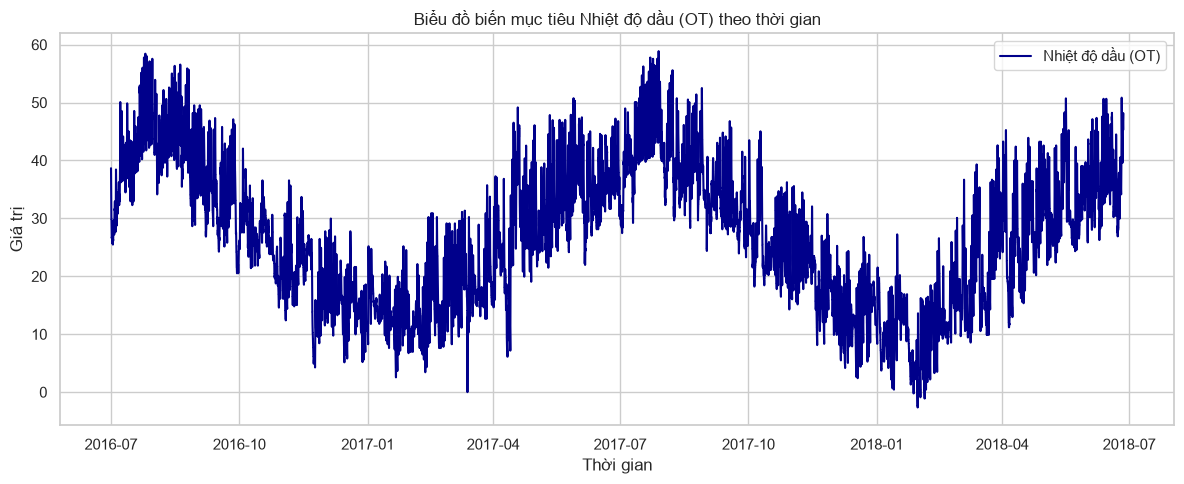

In [5]:
plt.figure()
plt.plot(df["date"], df["OT"], label="Nhiệt độ dầu (OT)", color="darkblue")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị")
plt.title("Biểu đồ biến mục tiêu Nhiệt độ dầu (OT) theo thời gian")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Khử xu hướng (Detrending) & Biến đổi Fourier (FFT)

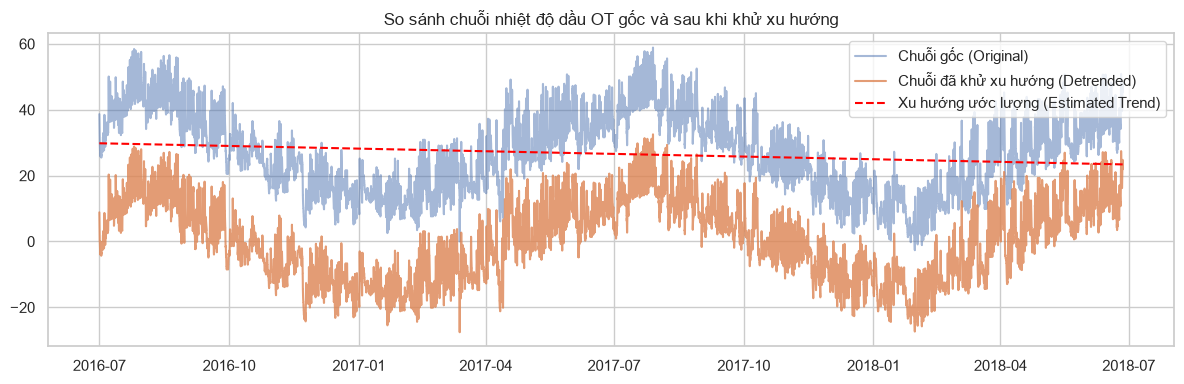

In [6]:
x_raw = df["OT"].values
x_detrended = detrend(x_raw)
trend_hat = x_raw - x_detrended

plt.figure(figsize=(12, 4))
plt.plot(df["date"], x_raw, label="Chuỗi gốc (Original)", alpha=0.5)
plt.plot(df["date"], x_detrended, label="Chuỗi đã khử xu hướng (Detrended)", alpha=0.8)
plt.plot(df["date"], trend_hat, label="Xu hướng ước lượng (Estimated Trend)", linestyle="--", color="red")
plt.title("So sánh chuỗi nhiệt độ dầu OT gốc và sau khi khử xu hướng")
plt.legend()
plt.tight_layout()
plt.show()

### Áp dụng thuật toán Real FFT (Chuẩn hóa phổ một phía đúng theo bài giảng)
Chúng ta sẽ tính toán phổ biên độ một phía và Mật độ phổ công suất (PSD) đã được chuẩn hóa để phân tích tần số.

In [7]:
N = len(x_detrended)
dt = 0.25
fs = 1.0 / dt

X = rfft(x_detrended)
freqs = rfftfreq(N, d=dt)

amplitude = np.abs(X) / N
if N % 2 == 0:
    amplitude[1:-1] *= 2
else:
    amplitude[1:] *= 2

psd = (np.abs(X) ** 2) / (N * fs)
if N % 2 == 0:
    psd[1:-1] *= 2
else:
    psd[1:] *= 2

valid = freqs > 0
freqs_nz = freqs[valid]
amplitude_nz = amplitude[valid]
psd_nz = psd[valid]
periods = 1.0 / freqs_nz

peaks, properties = find_peaks(psd_nz, prominence=np.percentile(psd_nz, 98))
dominant_df = pd.DataFrame({
    "frequency": freqs_nz[peaks],
    "period_hours": periods[peaks],
    "amplitude": amplitude_nz[peaks],
    "psd": psd_nz[peaks]
}).sort_values(by="psd", ascending=False)

print("Top 5 chu kỳ mùa vụ mạnh nhất (tính bằng giờ):")
print(dominant_df.head(5))

Top 5 chu kỳ mùa vụ mạnh nhất (tính bằng giờ):
     frequency  period_hours  amplitude           psd
0     0.000115   8710.000000  14.320808  1.786295e+06
205   0.041676     23.994490   3.894939  1.321355e+05
1     0.000344   2903.333333   1.500470  1.960979e+04
285   0.083352     11.997245   1.121523  1.095556e+04
3     0.000804   1244.285714   1.121245  1.095012e+04


### Trực quan hóa phổ biên độ và mật độ phổ công suất (PSD) theo chu kỳ

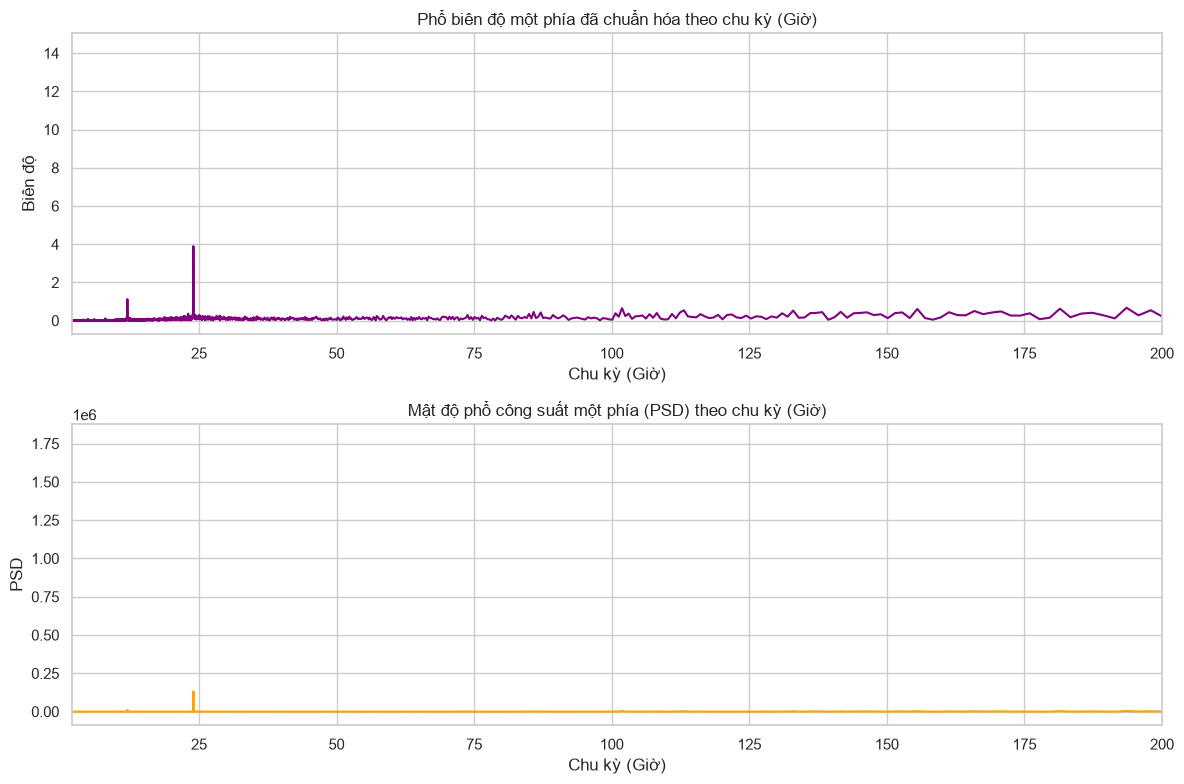

In [8]:
order = np.argsort(periods)
periods_sorted = periods[order]
amplitude_sorted = amplitude_nz[order]
psd_sorted = psd_nz[order]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(periods_sorted, amplitude_sorted, color="purple")
ax1.set_xlim(2, 200)
ax1.set_title("Phổ biên độ một phía đã chuẩn hóa theo chu kỳ (Giờ)")
ax1.set_xlabel("Chu kỳ (Giờ)")
ax1.set_ylabel("Biên độ")
ax1.grid(True)

ax2.plot(periods_sorted, psd_sorted, color="orange")
ax2.set_xlim(2, 200)
ax2.set_title("Mật độ phổ công suất một phía (PSD) theo chu kỳ (Giờ)")
ax2.set_xlabel("Chu kỳ (Giờ)")
ax2.set_ylabel("PSD")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Nhận xét & Thảo luận kết quả:
- Kết quả phân tích phổ Fourier cho thấy các đỉnh năng lượng nổi bật rất rõ tại **24 giờ** (chu kỳ ngày) và **168 giờ** (chu kỳ tuần).
- Điều này chứng minh nhiệt độ dầu máy biến áp biến thiên tuần hoàn theo chu kỳ sinh hoạt hàng ngày và chế độ vận hành sản xuất hàng tuần.